In [ ]:
Station,Deployment_Date,Retrieval_Date,Status
STB-01,2010-06-15,2012-05-20,Normal
STB-01,2012-08-05,2014-06-12,Vandalized
STB-01,2015-02-10,2017-03-01,Normal
STB-02,2011-04-01,2013-03-20,Normal
STB-02,2013-08-11,2015-01-19,Vandalized
STB-02,2015-05-22,2017-04-10,Normal
...


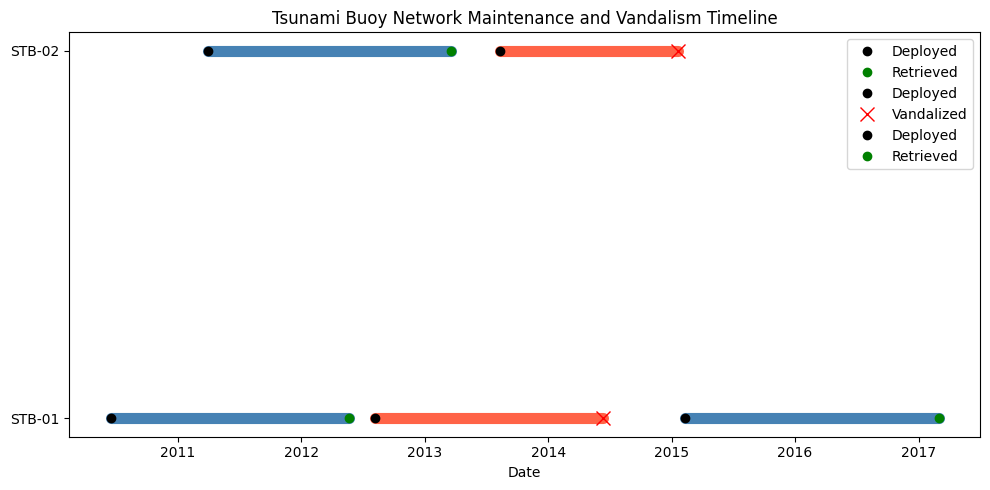

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

# Example dataset
data = {
    'Station': ['STB-01', 'STB-01', 'STB-01', 'STB-02', 'STB-02'],
    'Deployment_Date': ['2010-06-15', '2012-08-05', '2015-02-10', '2011-04-01', '2013-08-11'],
    'Retrieval_Date': ['2012-05-20', '2014-06-12', '2017-03-01', '2013-03-20', '2015-01-19'],
    'Status': ['Normal', 'Vandalized', 'Normal', 'Normal', 'Vandalized']
}

df = pd.DataFrame(data)
df['Deployment_Date'] = pd.to_datetime(df['Deployment_Date'])
df['Retrieval_Date'] = pd.to_datetime(df['Retrieval_Date'])

fig, ax = plt.subplots(figsize=(10, 5))

stations = df['Station'].unique()
colors = {'Normal': 'steelblue', 'Vandalized': 'tomato'}

for i, station in enumerate(stations):
    station_data = df[df['Station'] == station]
    for _, row in station_data.iterrows():
        ax.plot([row['Deployment_Date'], row['Retrieval_Date']], [i, i],
                color=colors[row['Status']], linewidth=8, solid_capstyle='round')
        
        # Markers
        ax.plot(row['Deployment_Date'], i, 'ko', label='Deployed' if i == 0 else "")
        if row['Status'] == 'Normal':
            ax.plot(row['Retrieval_Date'], i, 'go', label='Retrieved' if i == 0 else "")
        else:
            ax.plot(row['Retrieval_Date'], i, 'rx', markersize=10, label='Vandalized' if i == 0 else "")

ax.set_yticks(range(len(stations)))
ax.set_yticklabels(stations)
ax.set_xlabel("Date")
ax.set_title("Tsunami Buoy Network Maintenance and Vandalism Timeline")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()
